In [1]:
import json
import matplotlib.pyplot as plt

with open(
    "../outputs/training_history.json"
) as f:
    history = json.load(f)

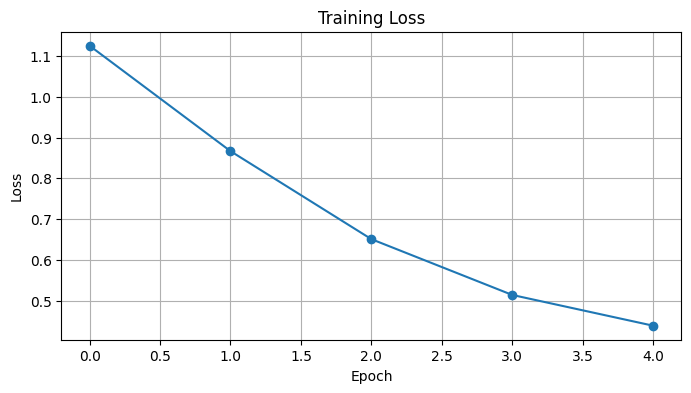

In [2]:
plt.figure(figsize=(8,4))

plt.plot(
    history["train_loss"],
    marker="o"
)

plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid()

plt.show()

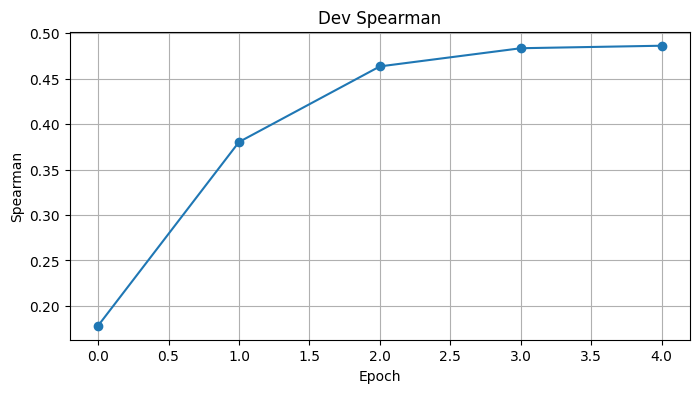

Best Spearman: 0.48639874890330836


In [3]:
plt.figure(figsize=(8,4))

plt.plot(
    history["dev_spearman"],
    marker="o"
)

plt.title("Dev Spearman")
plt.xlabel("Epoch")
plt.ylabel("Spearman")

plt.grid()

plt.show()

print(
    "Best Spearman:",
    max(history["dev_spearman"])
)

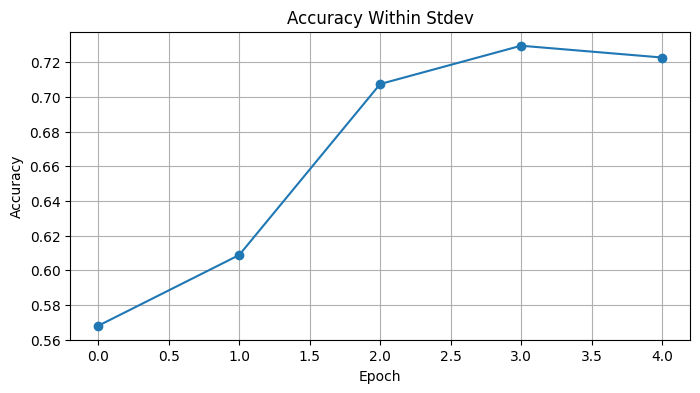

In [4]:
plt.figure(figsize=(8,4))

plt.plot(
    history["dev_acc"],
    marker="o"
)

plt.title("Accuracy Within Stdev")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid()

plt.show()

In [5]:
import json
import pandas as pd

with open("../data/dev.json") as f:
    dev_data = json.load(f)

rows = []

for sample in dev_data.values():

    rows.append({
        "word": sample["homonym"],
        "gold": sample["average"],
        "stdev": sample["stdev"]
    })

df = pd.DataFrame(rows)

df.head()

,word,gold,stdev
0,track,3.6,1.673320
1,track,3.6,0.547723
2,track,3.8,1.303840
3,track,4.2,0.836660
4,track,3.0,1.870829


In [7]:
import torch
import torch.nn as nn
class PlausibilityModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.backbone = AutoModel.from_pretrained(MODEL_NAME)

        hidden = self.backbone.config.hidden_size

        self.head = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden, 1)
        )

    def mean_pool(self, outputs, mask):

        token_embeddings = outputs.last_hidden_state

        mask = mask.unsqueeze(-1)

        return (token_embeddings * mask).sum(1) / mask.sum(1)

    def forward(self, input_ids, attention_mask):

        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        pooled = self.mean_pool(outputs, attention_mask)

        return self.head(pooled).squeeze(-1)


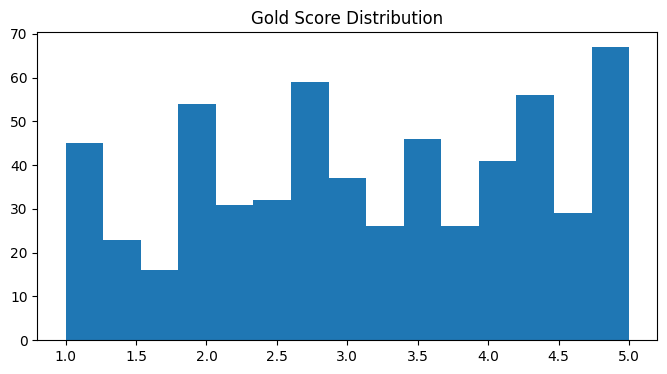

In [8]:
plt.figure(figsize=(8,4))

plt.hist(
    df["gold"],
    bins=15
)

plt.title("Gold Score Distribution")

plt.show()